In [1]:
from pyhgf.model import Network
import numpy as np
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
import pytensor.tensor as pt
import pymc as pm
from scipy.stats import norm
from pathlib import Path
import jax.numpy as jnp
from jax.scipy.stats import norm
from pyhgf.math import binary_surprise
from utils import extract_psychometric, cumulative_normal
from distributions import get_cardioception_hgf
from jax import config

config.update("jax_enable_x64", True)

plt.rcParams["figure.constrained_layout.use"] = True

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [2]:
hrd_path = Path.cwd().parent / "data" / "hrd.csv"
hrd_df = pd.read_csv(hrd_path, index_col=0, low_memory=False)
hrd_df = hrd_df[hrd_df.task == "hrd-session2"]

In [39]:
participant_id = "sub-0127"
df = hrd_df[hrd_df.participant_id == participant_id]
df.head()

,participant_id,id,task,cohort,StaircaseType,Condition,Modality,Decision,DecisionRT,Confidence,...,nTrials,EstimatedThreshold,EstimatedSlope,StartListening,StartDecision,ResponseMade,RatingStart,RatingEnds,endTrigger,session
25881,sub-0127,127,hrd-session2,vmp1,psi,Less,Intero,NaN,NaN,NaN,...,0,22.805550,12.549457,1.602849e+09,1.602849e+09,1.602849e+09,NaN,NaN,1.602849e+09,2
25882,sub-0127,127,hrd-session2,vmp1,psi,Less,Extero,More,2.099876,30.0,...,1,-23.245423,12.550553,1.602849e+09,1.602849e+09,1.602849e+09,1.602849e+09,1.602849e+09,1.602849e+09,2
25883,sub-0127,127,hrd-session2,vmp1,psi,More,Intero,More,1.599438,100.0,...,2,10.001882,12.884902,1.602849e+09,1.602849e+09,1.602849e+09,1.602849e+09,1.602849e+09,1.602849e+09,2
25884,sub-0127,127,hrd-session2,vmp1,psi,More,Intero,More,4.282859,43.0,...,3,0.998384,13.044744,1.602849e+09,1.602849e+09,1.602849e+09,1.602849e+09,1.602849e+09,1.602849e+09,2
25885,sub-0127,127,hrd-session2,vmp1,psi,Less,Intero,More,2.832672,25.0,...,4,-8.641712,15.504796,1.602849e+09,1.602849e+09,1.602849e+09,1.602849e+09,1.602849e+09,1.602849e+09,2


In [40]:
heart_rate = df[df.Modality == "Intero"].listenBPM.to_numpy()
intero_tone_2 = df[df.Modality == "Intero"].responseBPM.to_numpy()
extero_tone_1 = df[df.Modality == "Extero"].listenBPM.to_numpy()
extero_tone_2 = df[df.Modality == "Extero"].responseBPM.to_numpy()

extero_decision = (df[df.Modality == "Extero"].Decision.to_numpy() == "More").astype(
    int
)
intero_decision = (df[df.Modality == "Intero"].Decision.to_numpy() == "More").astype(
    int
)

## Predictive coding

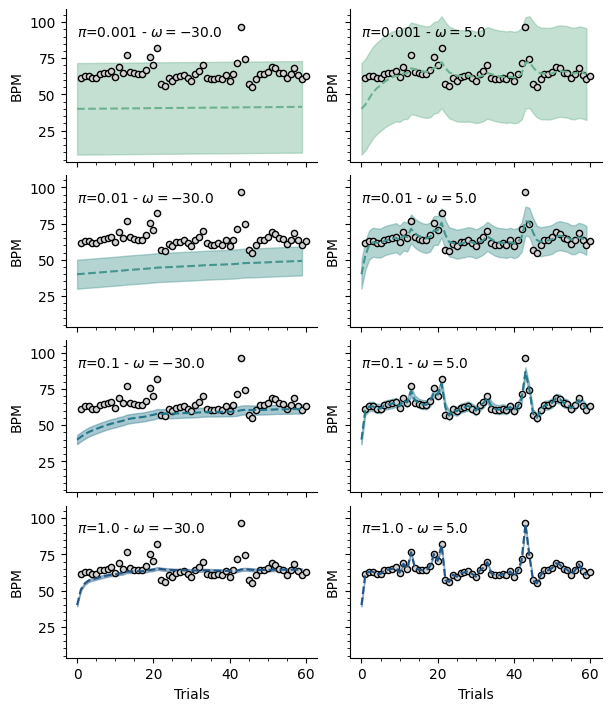

In [48]:
_, axs = plt.subplots(figsize=(6, 7), nrows=4, ncols=2, sharex=True, sharey=True)

colors = sns.color_palette("crest", n_colors=4)
x = np.arange(0, len(heart_rate))
for i, tonic_volatility in enumerate([-30.0, 5.0]):
    for ii, precision, color in zip(range(5), [0.001, 0.01, 0.1, 1.0], colors):
        network = (
            Network(update_type="unbounded")
            .add_nodes(precision=precision, expected_precision=precision)
            .add_nodes(value_children=0, mean=40.0, tonic_volatility=tonic_volatility)
            .add_nodes(volatility_children=1)
        )

        network.input_data(input_data=heart_rate)
        std = np.sqrt(1 / network.node_trajectories[0]["expected_precision"])
        axs[ii, i].fill_between(
            x=x,
            y1=network.node_trajectories[0]["expected_mean"] - std,
            y2=network.node_trajectories[0]["expected_mean"] + std,
            color=color,
            alpha=0.4,
        )
        axs[ii, i].plot(
            x,
            network.node_trajectories[0]["expected_mean"],
            linestyle="--",
            color=color,
        )

        axs[ii, i].scatter(
            np.arange(1, len(heart_rate) + 1),
            heart_rate,
            s=20,
            color="lightgrey",
            edgecolor="k",
        )

        axs[ii, i].text(
            0, 90, rf"$\pi$={precision} - $\omega = {tonic_volatility}$", fontsize=10
        )

        axs[ii, i].set(ylabel="BPM")
        axs[ii, i].minorticks_on()

axs[-1, 0].set(xlabel="Trials")
axs[-1, 1].set(xlabel="Trials")
sns.despine()
plt.savefig(Path().cwd().parents[0] / "figures" / "fig_4_hgf_precision.svg")

## Cardiac Interoception HGF

In [6]:
input_data = heart_rate
observed = np.ones(len(heart_rate))
response_function_inputs = (
    intero_decision,
    intero_tone_2,
    extero_decision,
    extero_tone_1,
    extero_tone_2,
)

In [7]:
cardioception_hgf_pointwise_op = get_cardioception_hgf(
    input_data=input_data,
    observed=observed,
    response_function_inputs=response_function_inputs,
    pointwise=True,
)

In [8]:
cardioception_hgf_op = get_cardioception_hgf(
    input_data=input_data,
    observed=observed,
    response_function_inputs=response_function_inputs,
    pointwise=False,
)


def logp(value, tonic_volatility, cardiac_precision, cardiac_mean, auditory_precision):
    """Log probability function."""
    return cardioception_hgf_op(
        pt.squeeze(tonic_volatility),
        pt.squeeze(cardiac_precision),
        pt.squeeze(cardiac_mean),
        pt.squeeze(auditory_precision),
    )

In [53]:
with pm.Model() as two_level_model:
    tonic_volatility = pm.Normal("tonic_volatility", 0.0, 30.0)
    cardiac_precision = pm.Uniform("cardiac_precision", 0.1, 30)
    cardiac_mean = pm.Uniform("cardiac_mean", 20.0, 120.0)
    auditory_precision = pm.Uniform("auditory_precision", 0.1, 20)

    # log-likelihoods
    # ---------------
    log_likelihood = pm.CustomDist(
        "log_likelihood",
        tonic_volatility,
        1 / cardiac_precision**2,
        cardiac_mean,
        1 / auditory_precision**2,
        logp=logp,
        observed=intero_decision,
    )

    # pointwise log-likelihoods
    # -------------------------
    # pm.Deterministic(
    #    "pointwise_loglikelihood",
    #    cardioception_hgf_pointwise_op(
    #        tonic_volatility,
    #        1 / cardiac_precision**2,
    #        cardiac_mean,
    #        1 / auditory_precision**2,
    #    ),
    # )

    idata_two_level = pm.sample(
        chains=4,
        cores=4,
        n_init=1000,
        jitter_max_retries=5000,
        tune=4000,
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [tonic_volatility, cardiac_precision, cardiac_mean, auditory_precision]
/home/nicolas/.local/share/uv/python/cpython-3.12.10-linux-x86_64-gnu/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Output()

/home/nicolas/.local/share/uv/python/cpython-3.12.10-linux-x86_64-gnu/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Sampling 4 chains for 4_000 tune and 1_000 draw iterations (16_000 + 4_000 draws total) took 17 seconds.
There were 183 divergences after tuning. Increase `target_accept` or reparameterize.


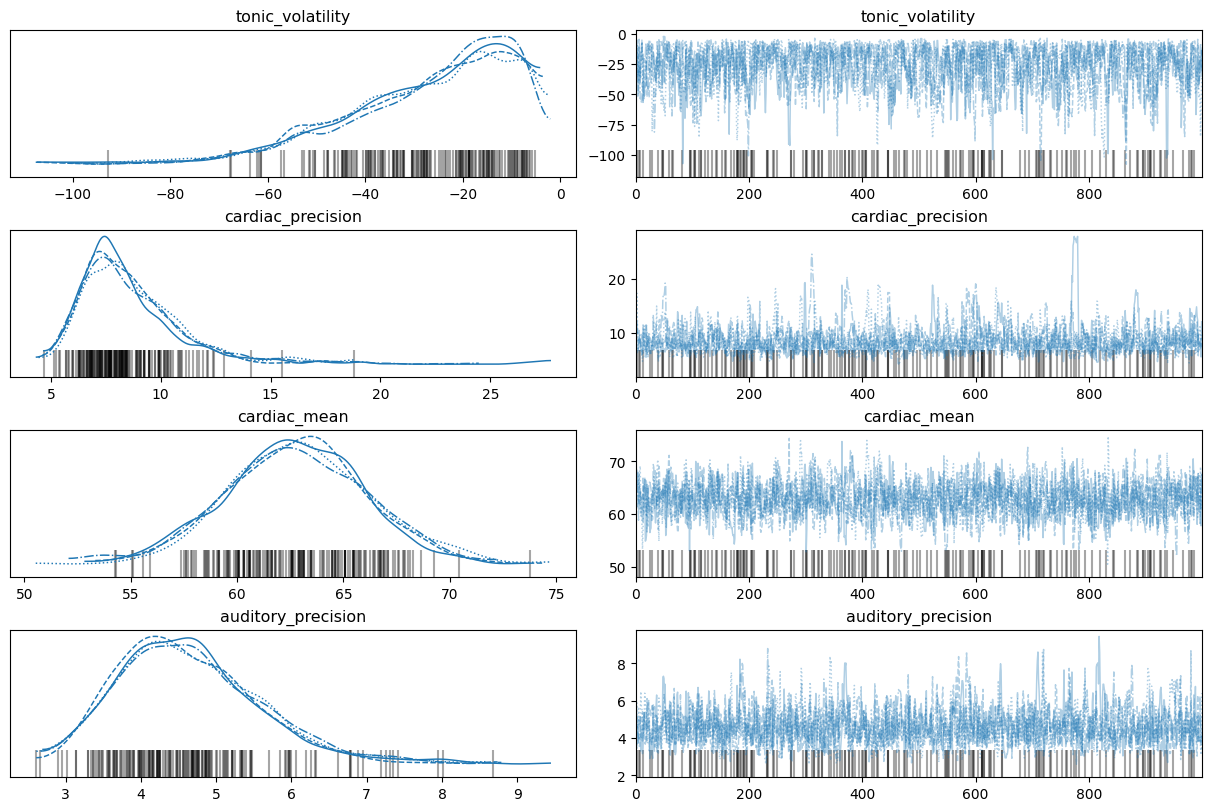

In [54]:
az.plot_trace(idata_two_level);

In [55]:
cardiac_precision = 1 / az.summary(idata_two_level)["mean"].cardiac_precision ** 2
auditory_precision = 1 / az.summary(idata_two_level)["mean"].auditory_precision ** 2
tonic_volatility = az.summary(idata_two_level)["mean"].tonic_volatility
cardiac_mean = az.summary(idata_two_level)["mean"].cardiac_mean

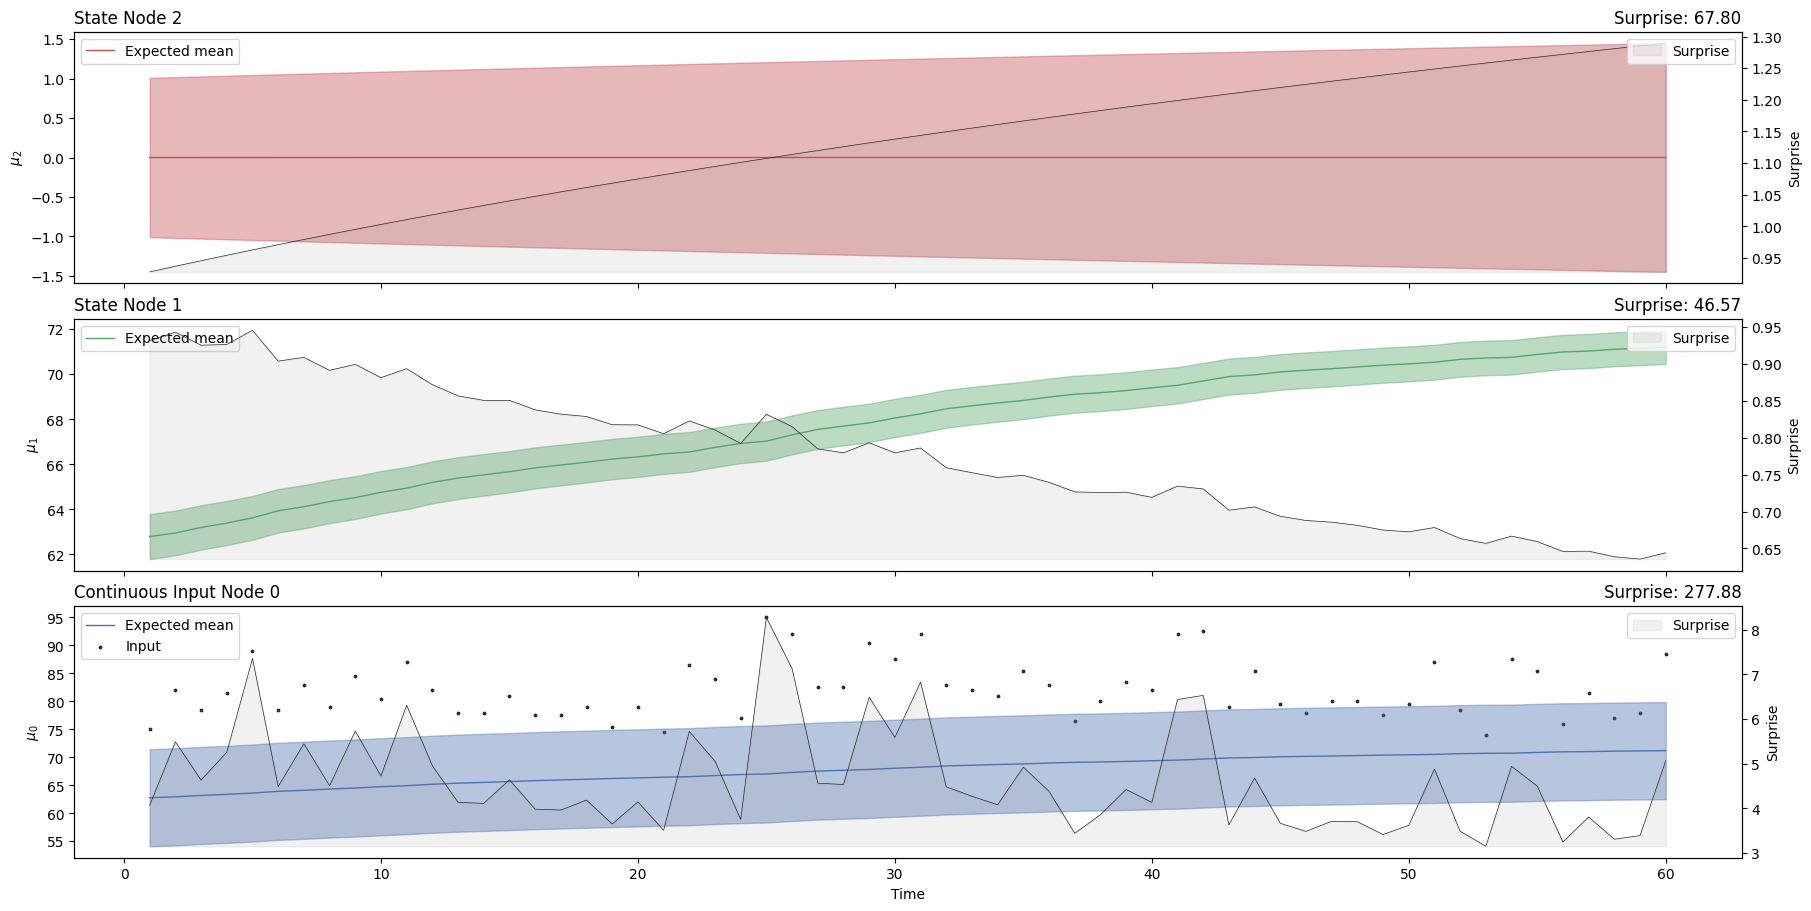

In [56]:
# create the probabilistic network
cardioception_hgf = (
    Network(update_type="unbounded")
    .add_nodes()
    .add_nodes(value_children=0)
    .add_nodes(volatility_children=1)
)
cardioception_hgf.attributes[0]["precision"] = cardiac_precision
cardioception_hgf.attributes[0]["expected_precision"] = cardiac_precision
cardioception_hgf.attributes[1]["tonic_volatility"] = tonic_volatility
cardioception_hgf.attributes[1]["mean"] = cardiac_mean

cardioception_hgf.input_data(
    input_data=input_data,
    observed=observed,
).plot_trajectories();

In [24]:
cardiac_precision

np.float64(0.012960308691742892)

(array([ 1.,  0.,  0.,  0.,  0.,  0.,  1.,  1.,  0., 57.]),
 array([0.00066653, 0.00072931, 0.00079209, 0.00085487, 0.00091765,
        0.00098043, 0.0010432 , 0.00110598, 0.00116876, 0.00123154,
        0.00129432]),
 <BarContainer object of 10 artists>)

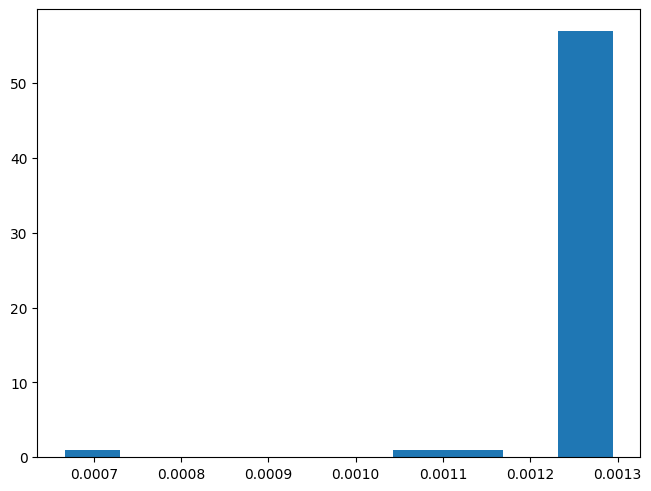

In [26]:
plt.hist(
    cardiac_precision / (network.node_trajectories[1]["precision"] + cardiac_precision)
)

ValueError: Too many bins for data range. Cannot create 10 finite-sized bins.

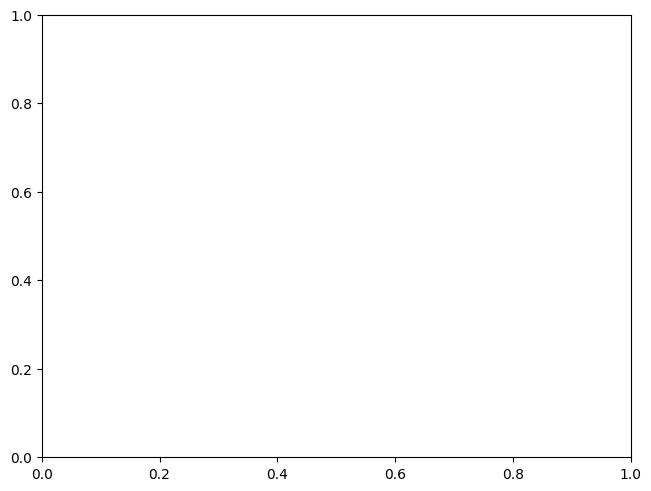

In [22]:
plt.hist(
    (
        network.node_trajectories[1]["precision"]
        - network.node_trajectories[1]["expected_precision"]
    )
    / cardiac_precision
)

array([<Axes: title={'center': 'auditory_precision'}>,
       <Axes: title={'center': 'cardiac_precision'}>], dtype=object)

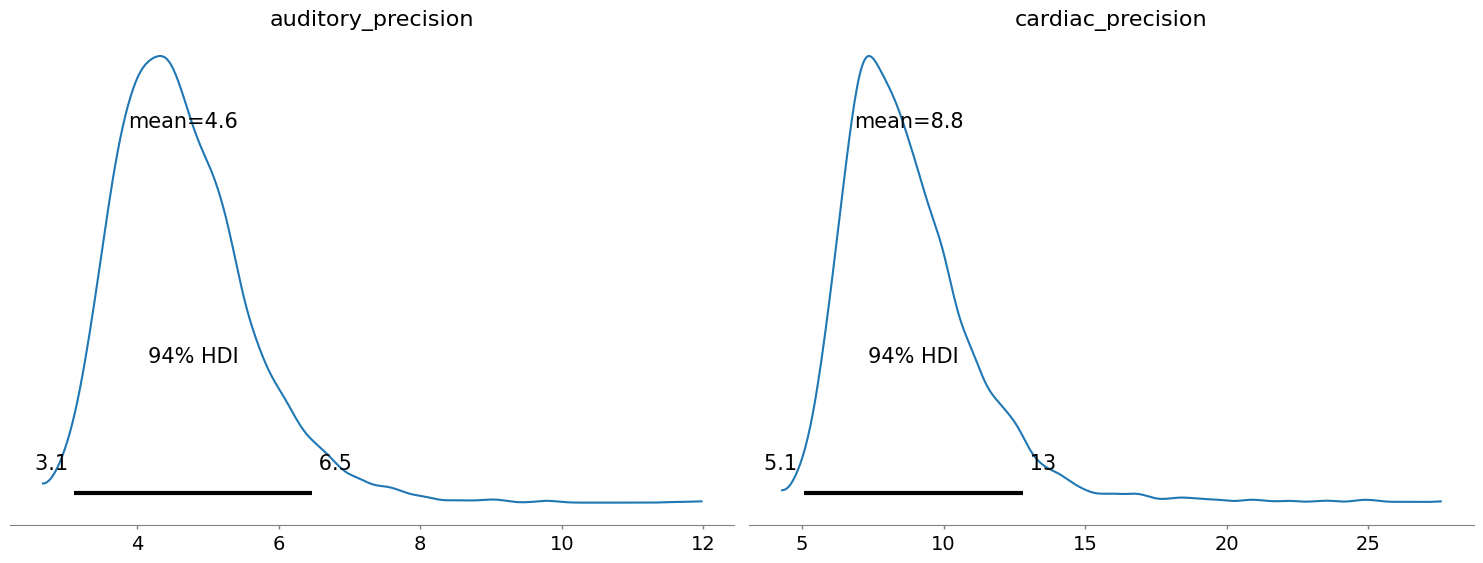

In [13]:
az.plot_posterior(
    idata_two_level, var_names=["auditory_precision", "cardiac_precision"]
)

In [ ]:
a

In [14]:
-cardioception_hgf.input_data(input_data=input_data, observed=observed).surprise(
    response_function=response_function,
    response_function_inputs=response_function_inputs,
    response_function_parameters=(auditory_precision,),
)

NameError: name 'response_function' is not defined

In [ ]:
def response_function(
    hgf: Network,
    response_function_inputs: tuple,
    response_function_parameters: tuple,
    pointwise: bool = False,
):
    """Response function."""
    intero_decision, intero_tone_2, extero_decision, extero_tone_1, extero_tone_2 = (
        response_function_inputs
    )
    auditory_precision = response_function_parameters[0]

    # exteroception --------------------------------------------------------------------
    threshold = extero_tone_2 - extero_tone_1
    slope = jnp.sqrt(2 / auditory_precision)
    extero_surprise = binary_surprise(
        x=extero_decision, expected_mean=1.0 - norm.cdf(0, loc=threshold, scale=slope)
    )

    print(1.0 - norm.cdf(0, loc=threshold, scale=slope))

    # interoception --------------------------------------------------------------------
    # threshold = intero_tone_2 - hgf.node_trajectories[1]["mean"]
    # slope = jnp.sqrt(
    #     (1 / auditory_precision) + (1 / hgf.node_trajectories[0]["precision"])
    # )
    # intero_surprise = binary_surprise(
    #     x=intero_decision, expected_mean=1.0 - norm.cdf(0, loc=threshold, scale=slope)
    # )
    intero_surprise = jnp.zeros(2)
    if pointwise:
        return -jnp.concat([extero_surprise, intero_surprise])
    else:
        return -jnp.sum(jnp.concat([extero_surprise, intero_surprise]))

In [ ]:
# create the probabilistic network
cardioception_hgf = (
    Network(update_type="unbounded")
    .add_nodes()
    .add_nodes(value_children=0, mean=60.0, tonic_volatility=-5.0)
    .add_nodes(volatility_children=0, mean=2.0)
)

cardioception_hgf.input_data(
    input_data=input_data,
    observed=observed,
).plot_trajectories();